In [68]:
# ╔══════════════════════════════════════════════════════════╗
# ║              Exploratory Data Analysis                   ║
# ╚══════════════════════════════════════════════════════════╝

In [69]:
# ── Imports Libraries ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
#pd.set_option("display.float_format", "{:,.2f}".format)

In [70]:
# ── Load Raw Data ─────────────────────────────────
df = pd.read_csv("../dataset/cleaned/housing_cleaned.csv")
print("Shape:", df.shape)
df.tail()

Shape: (27189, 9)


,City,Price,Number_Beds,Number_Baths,Province,Population,Latitude,Longitude,Median_Family_Income
27184,Halifax,"679,000.00",3.00,4.00,Nova Scotia,431479,44.89,63.10,"86,753.00"
27185,Halifax,"580,000.00",3.00,1.00,Nova Scotia,431479,44.89,63.10,"86,753.00"
27186,Halifax,"6,990,000.00",5.00,5.00,Nova Scotia,431479,44.89,63.10,"86,753.00"
27187,Halifax,"949,900.00",3.00,1.00,Nova Scotia,431479,44.89,63.10,"86,753.00"
27188,Halifax,"592,900.00",2.00,1.00,Nova Scotia,431479,44.89,63.10,"86,753.00"


In [71]:
# ── Cell 3: Basic Info ────────────────────────────────────
print("── Data Types ──")
print(df.dtypes)

print("\n── Missing Values ──")
print(df.isnull().sum())

print("\n── Basic Stats ──")
df.describe()

── Data Types ──
City                     object
Price                   float64
Number_Beds             float64
Number_Baths            float64
Province                 object
Population                int64
Latitude                float64
Longitude               float64
Median_Family_Income    float64
dtype: object

── Missing Values ──
City                    0
Price                   0
Number_Beds             0
Number_Baths            0
Province                0
Population              0
Latitude                0
Longitude               0
Median_Family_Income    0
dtype: int64

── Basic Stats ──


,Price,Number_Beds,Number_Baths,Population,Latitude,Longitude,Median_Family_Income
count,"27,189.00","27,189.00","27,189.00","27,189.00","27,189.00","27,189.00","27,189.00"
mean,"1,037,925.35",3.46,2.67,"641,115.43",47.34,-98.67,"89,908.57"
std,"1,126,489.56",1.77,1.42,"1,127,167.55",3.29,22.88,"12,556.20"
min,"21,500.00",1.00,1.00,"63,382.00",42.28,-123.94,"62,400.00"
25%,"499,000.00",2.00,2.00,"108,843.00",43.87,-122.60,"82,000.00"
50%,"749,900.00",3.00,2.00,"242,460.00",48.43,-104.61,"88,000.00"
75%,"1,199,900.00",4.00,3.00,"729,560.00",49.69,-79.68,"97,000.00"
max,"37,000,000.00",109.00,59.00,"5,647,656.00",53.92,63.10,"133,000.00"


In [72]:
# ── Price Summary Stats ─────────────────────────
print("── Price Summary ──")
print(f"Min    : ${df['Price'].min():,.0f}")
print(f"Max    : ${df['Price'].max():,.0f}")
print(f"Mean   : ${df['Price'].mean():,.0f}")
print(f"Median : ${df['Price'].median():,.0f}")
print(f"Std    : ${df['Price'].std():,.0f}")

── Price Summary ──
Min    : $21,500
Max    : $37,000,000
Mean   : $1,037,925
Median : $749,900
Std    : $1,126,490


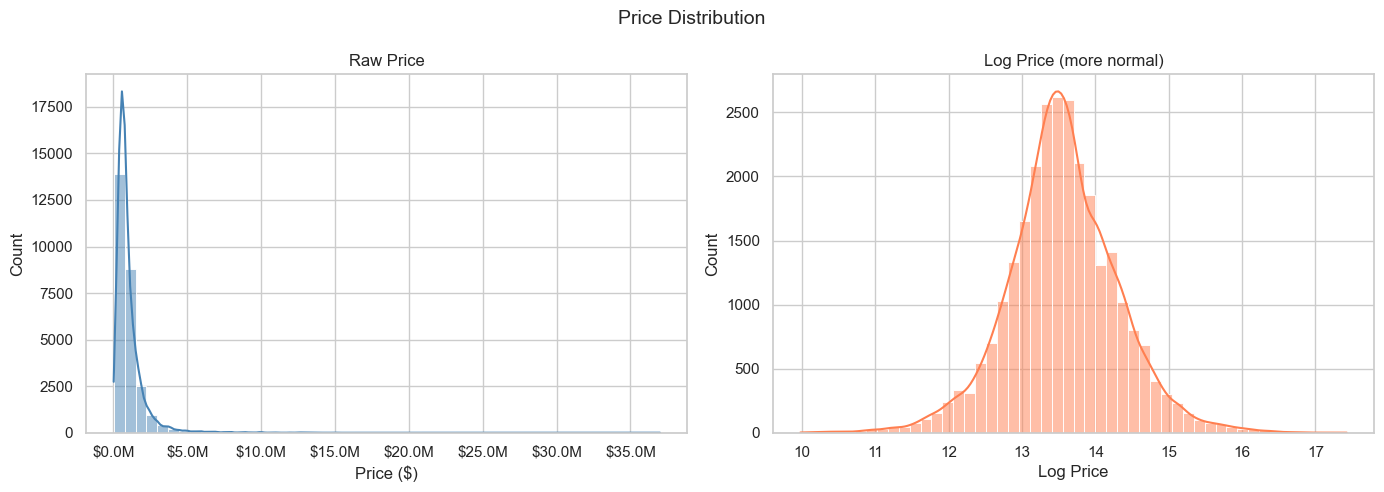

In [73]:
# ── Price Distribution ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Price Distribution", fontsize=14)

# Raw price is highly skewed, log transformation makes it more normal
sns.histplot(df["Price"], ax=axes[0], kde=True, color="steelblue", bins=50)
axes[0].set_title("Raw Price")
axes[0].set_xlabel("Price ($)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

# log transformation to reduce skewness and make it more normal for modeling
sns.histplot(np.log1p(df["Price"]), ax=axes[1], kde=True, color="coral", bins=50)
axes[1].set_title("Log Price (more normal)")
axes[1].set_xlabel("Log Price")

plt.tight_layout()
plt.savefig("../plots/01_price_distribution.png", dpi=150)
plt.show()

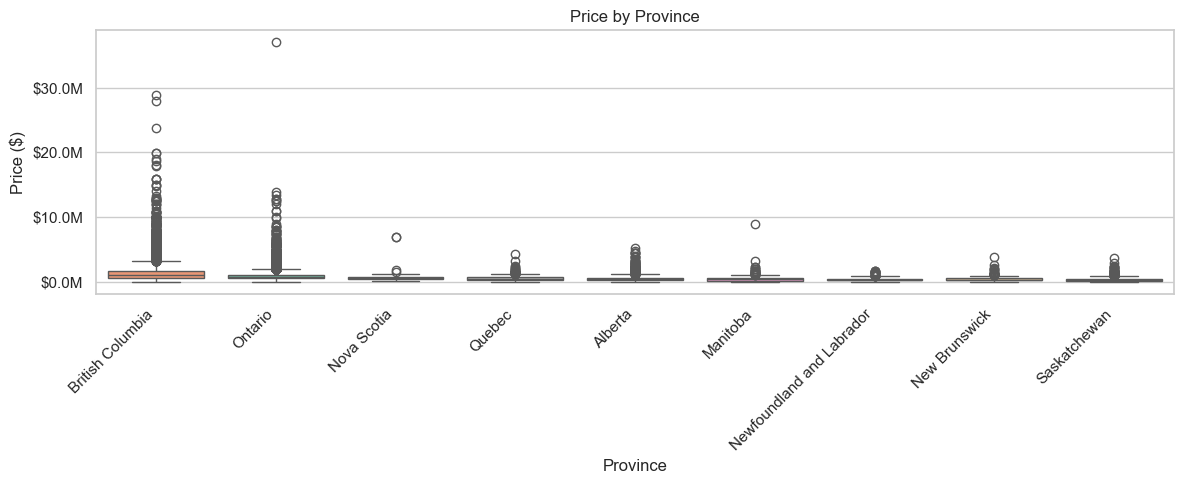

In [74]:
# ── Price by Province ───────────────────
plt.figure(figsize=(12, 5))
order = df.groupby("Province")["Price"].median().sort_values(ascending=False).index

sns.boxplot(x="Province", y="Price", data=df, order=order, hue="Province", palette="Set2")
plt.title("Price by Province")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

plt.tight_layout()
plt.savefig("../plots/02_price_by_province.png", dpi=150)
plt.show()

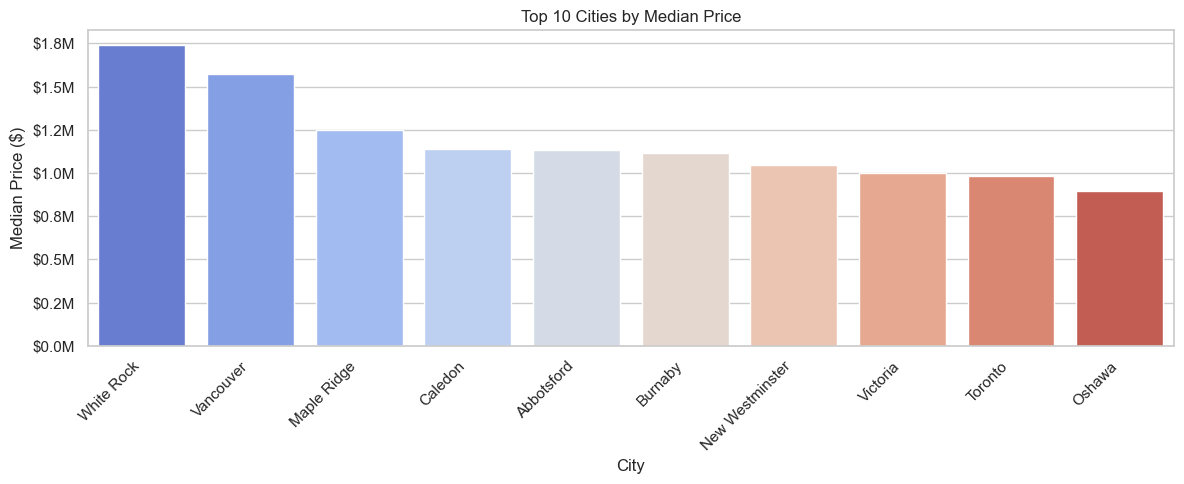

In [75]:
# ── Top 10 Cities by Median Price ────────────────
top_cities = df.groupby("City")["Price"].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_cities.index, y=top_cities.values, hue=top_cities.index, palette="coolwarm")
plt.title("Top 10 Cities by Median Price")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Median Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("../plots/03_top10_cities.png", dpi=150)
plt.show()

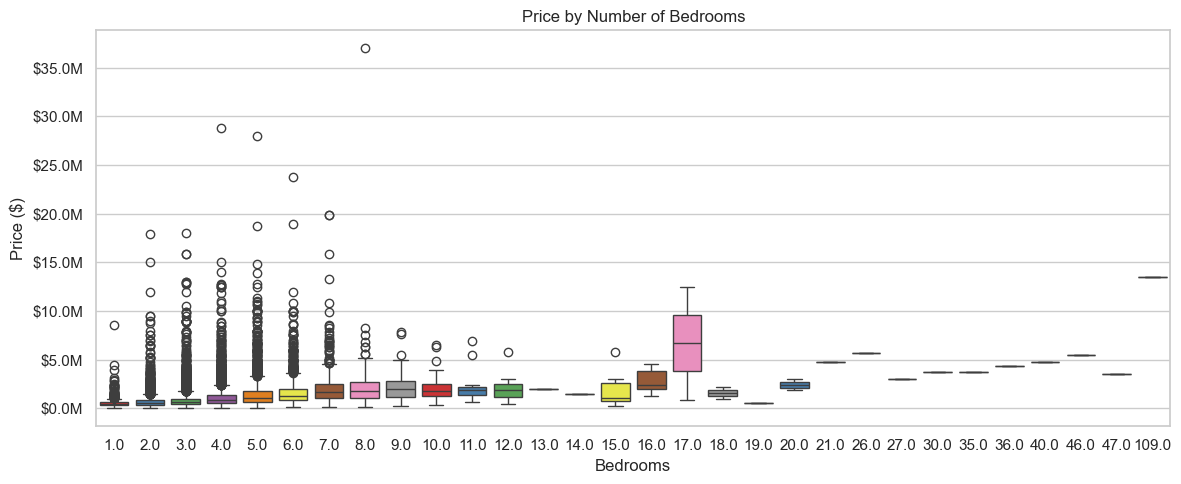

In [76]:
# ── Price by Bedrooms ─────────────────────────────
plt.figure(figsize=(12, 5))
sns.boxplot(x="Number_Beds", y="Price", data=df, hue="Number_Beds", legend=False, palette="Set1")
plt.title("Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("../plots/04_price_by_beds.png", dpi=150)
plt.show()

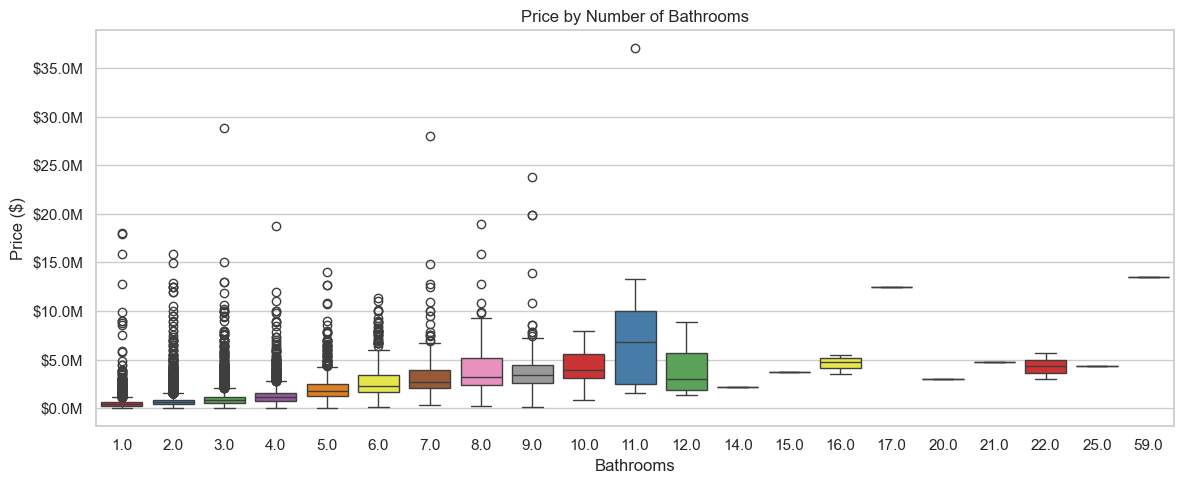

In [77]:
# ── Price by Bathrooms ────────────────────────────
plt.figure(figsize=(12, 5))
sns.boxplot(x="Number_Baths", y="Price", data=df, hue="Number_Baths", legend=False, palette="Set1")
plt.title("Price by Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("../plots/05_price_by_baths.png", dpi=150)
plt.show()

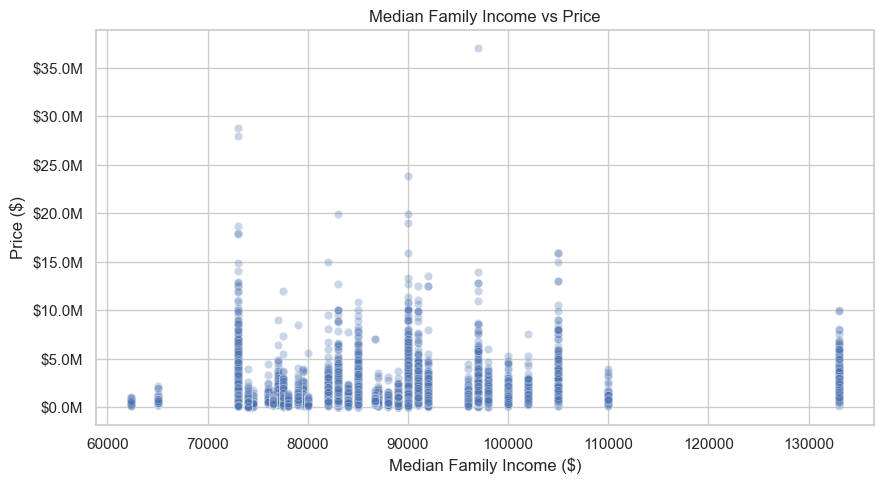

In [78]:
# ── Income vs Price ───────────────────────────────
plt.figure(figsize=(9, 5))
sns.scatterplot(x="Median_Family_Income", y="Price", data=df, alpha=0.3)
plt.title("Median Family Income vs Price")
plt.xlabel("Median Family Income ($)")
plt.ylabel("Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("../plots/06_income_vs_price.png", dpi=150)
plt.show()

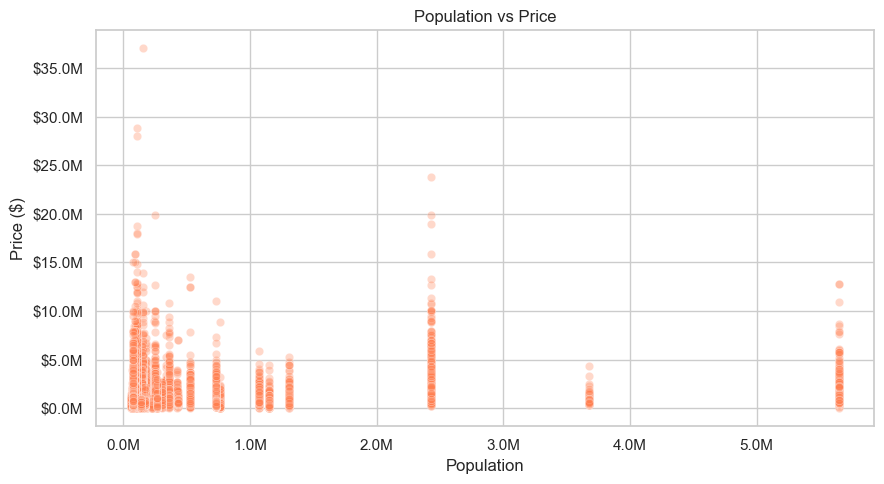

In [79]:
# ── Population vs Price ─────────────────────────
plt.figure(figsize=(9, 5))
sns.scatterplot(x="Population", y="Price", data=df, alpha=0.3, color="coral")
plt.title("Population vs Price")
plt.xlabel("Population")
plt.ylabel("Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("../plots/07_population_vs_price.png", dpi=150)
plt.show()

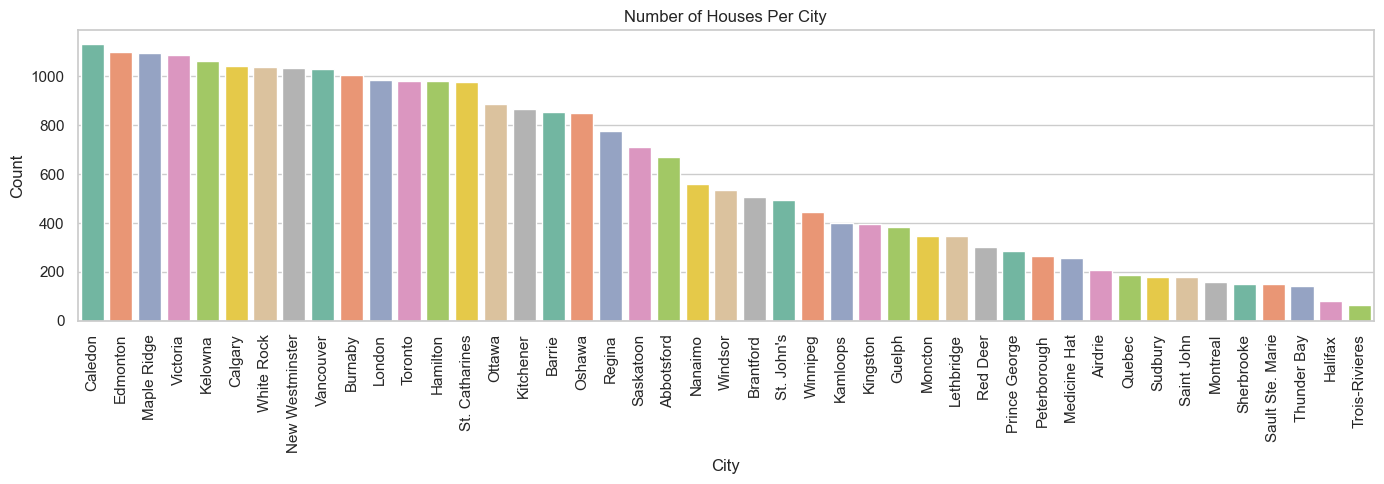

In [ ]:
plt.figure(figsize=(14, 5))
city_counts = df["City"].value_counts()
sns.barplot(x=city_counts.index, y=city_counts.values, hue=city_counts.index, palette="Set2")
plt.title("Number of Houses Per City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../plots/08_houses_per_city.png", dpi=150)
plt.show()

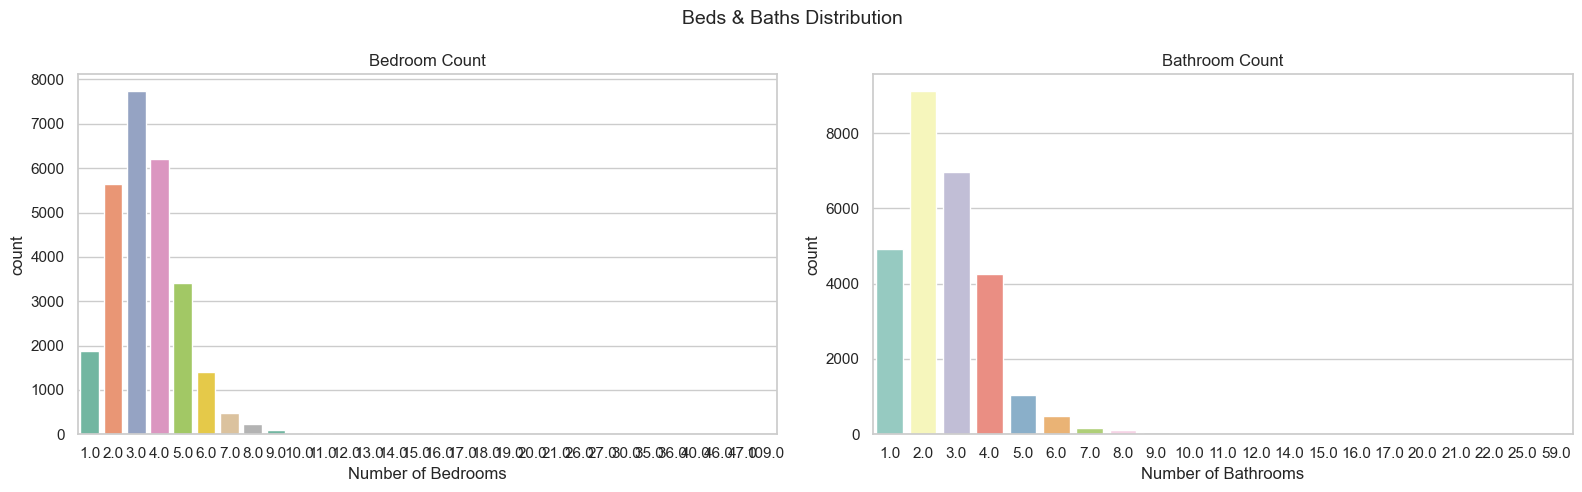

In [81]:
# ── Beds & Baths Count Distribution ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Beds & Baths Distribution", fontsize=14)

sns.countplot(x="Number_Beds",  data=df, ax=axes[0], hue="Number_Beds", legend=False, palette="Set2")
axes[0].set_title("Bedroom Count")
axes[0].set_xlabel("Number of Bedrooms")

sns.countplot(x="Number_Baths", data=df, ax=axes[1], hue="Number_Baths", legend=False, palette="Set3")
axes[1].set_title("Bathroom Count")
axes[1].set_xlabel("Number of Bathrooms")

plt.tight_layout()
plt.savefig("../plots/09_beds_baths_count.png", dpi=150)
plt.show()